In [1]:
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 15.5 MB/s eta 0:00:00a 0:00:01


In [2]:
import torch
import torch.optim
import torch.nn as nn
from torch.utils.data import dataloader
from torchvision.transforms import  transforms
import torchvision.utils as vutils
import numpy as np
from timeit import default_timer as timer
from tqdm.auto import tqdm 
import matplotlib.pyplot as plt
import lightning as L
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda) 

2.10.0+cu128
True
12.8


In [3]:
import os
from PIL import Image
from torch.utils.data import Dataset

class CelebA(Dataset):
  def __init__(self, root, transform=None):
    self.root = root
    # Filter for common image extensions to ensure only image files are loaded
    self.image_files = [f for f in os.listdir(root) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    self.transform = transform

  def __len__(self):
    return len(self.image_files)

  def __getitem__(self, idx):
    img_path = os.path.join(self.root, self.image_files[idx])
    img = Image.open(img_path).convert('RGB')
    if self.transform:
      img = self.transform(img)
    return img

In [4]:
data_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [5]:
dataroot = '/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba'
dataset = CelebA(root=dataroot, transform=data_transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True,  num_workers=2, drop_last=True)


In [6]:
#variance schedule
T = 1000
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end , steps=T)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)


In [7]:
#Forward pass 
def q_sample(x0, t, alphas_cumprod, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod[t]).view(-1, 1, 1, 1)
    
    return sqrt_alphas_cumprod * x0 + sqrt_one_minus_alphas_cumprod * noise

In [8]:
#SinusoidalPositionEmbeddings

import math 
import torch 

class Sinusoidal_Embeddings(torch.nn.Module):
    def __init__(self, dim:int):
        super().__init__()
        assert dim % 2 ==0 , 'Embeddings must be divisble by two to create to sin and cos waves'
        self.dim = dim
    def forward(self, time_stamps:torch.Tensor) -> torch.Tensor:
        device = time_stamps.device
        half_dim = self.dim // 2
        scale  = math.log(10000)/(half_dim - 1)
        freq = torch.exp(torch.arange(half_dim, dtype=torch.float32, device=device) * -scale)
        embeddings = time_stamps[:, None].float() * freq[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings 

In [9]:
#Time embeddings 

class Time_embeddings(torch.nn.Module):
    def __init__(self, time_emb_dim: int, out_dim: int):
        super().__init__()
        self.sinusoidal_emb = Sinusoidal_Embeddings(time_emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(time_emb_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim)
        )
    def forward(self, time_steps:torch.Tensor)-> torch.Tensor:
        raw_emb = self.sinusoidal_emb(time_steps)
        return self.mlp(raw_emb)

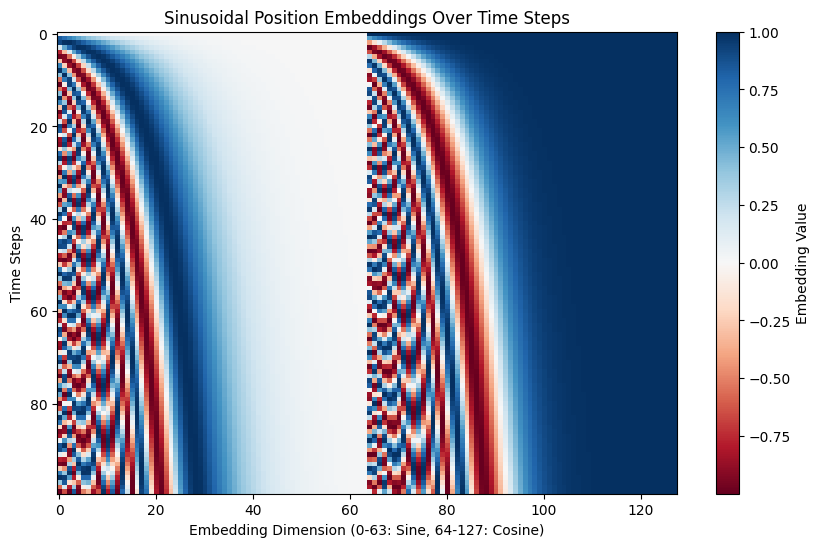

In [10]:
# 1. Instantiate the embedding layer with 128 dimensions
embedding_dim = 128
pos_embedding = Sinusoidal_Embeddings(dim=embedding_dim)

# 2. Create a batch of 100 chronological time steps (0 to 99)
time_stamps = torch.arange(100)

# 3. Generate the embeddings (Output shape will be)
embeddings = pos_embedding(time_stamps)

# 4. Plot the resulting matrix as a heatmap
plt.figure(figsize=(10, 6))
plt.imshow(embeddings.numpy(), cmap="RdBu", aspect="auto")
plt.colorbar(label="Embedding Value")
plt.title("Sinusoidal Position Embeddings Over Time Steps")
plt.xlabel("Embedding Dimension (0-63: Sine, 64-127: Cosine)")
plt.ylabel("Time Steps")
plt.show()


In [11]:
# Resblock

class ResBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.silu = nn.SiLU()
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        self.residual_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, time_emb):
        h = self.norm1(self.conv1(x))
        h = self.silu(h)
        time_proj = self.silu(self.time_mlp(time_emb))[:, :, None, None]    #(B, out_channels) → (B, out_channels, 1, 1)
        h = h + time_proj
        h = self.norm2(self.conv2(h))
        h = self.silu(h)
        return h + self.residual_conv(x)
        

In [12]:
#downsample and up sample
class Down_sample(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class Up_sample(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.transpose = nn.ConvTranspose2d(channels, channels, 4, stride=2, padding=1)
    def forward(self, x):
        return self.transpose(x)
        

In [13]:
#Self Attention block 
import torch.nn.functional as F

class Self_Attention(nn.Module):
    def __init__(self, channels, num_heads=8):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = channels // num_heads

        self.norm = nn.GroupNorm(32, channels)
        self.to_qkv = nn.Linear(channels, channels*3)
        self.proj_out = nn.Linear(channels, channels)

    def forward(self, x):
        b, c, h, w = x.shape
        x_norm = self.norm(x)
        x_flat = x_norm.view(b, c, h*w).transpose(2,1) # [batch, channels, h*w] -> [batch, h*w, channels]
        
        #Matrices for Query ,Key and Value
        qkv = self.to_qkv(x_flat)
        q,k,v = qkv.chunk(3, dim=-1)

        #Matrices for mutli-head splitting
        #[batch, h*w, channles]->[batch, h*w, num_heads, head_dim]->[batch, num_heads, h*w, head_dim]
        q = q.view(b, -1, self.num_heads, self.head_dim).transpose(1,2)
        k = k.view(b, -1, self.num_heads, self.head_dim).transpose(1,2)
        v = v.view(b, -1, self.num_heads, self.head_dim).transpose(1,2)
        
        #Calculate dot product for attebtion scores
        attn_out = F.scaled_dot_product_attention(q, k, v)

        #Projecting image 
        out = attn_out.transpose(1,2).reshape(b, h*w, c)
        out = self.proj_out(out)
        out = out.transpose(1,2).reshape(b, c, h, w)
        return x+out 


In [14]:
#Full Unet class 

class Unet(torch.nn.Module):
    def __init__(self, in_channels=3, time_emb_dim=128):
        super().__init__()
        #Time embedding dimemension
        self.time_emb = Time_embeddings(time_emb_dim, out_dim=256)

        #Encoder
        self.inc = nn.Conv2d(in_channels, 64, 3 ,padding=1)
        self.resblock1 = ResBlock(64, 64, time_emb_dim=256)
        self.resblock2 = ResBlock(64, 64, time_emb_dim=256)
        self.down1 = Down_sample(64)
        self.resblock3 = ResBlock(64, 128, time_emb_dim=256)
        self.resblock4 = ResBlock(128, 128, time_emb_dim=256)
        self.down2 = Down_sample(128)
        self.resblock5 = ResBlock(128, 256, time_emb_dim=256)
        self.resblock6 = ResBlock(256, 256, time_emb_dim=256)
        self.self_att1 = Self_Attention(256,8)
        self.down3 = Down_sample(256)
        self.resblock7= ResBlock(256, 512, time_emb_dim=256)
        self.resblock8= ResBlock(512, 512, time_emb_dim=256)

        #Bottelneck
        self.bott1 = ResBlock(512, 512, time_emb_dim=256)
        self.self_att2 = Self_Attention(512, 8)
        self.bott2 = ResBlock(512, 512, time_emb_dim=256)

        #Decoder
        self.resblock11 = ResBlock(1024, 512, time_emb_dim=256)
        self.resblock12 = ResBlock(1024, 512, time_emb_dim=256)
        self.up1 = Up_sample(512)
        self.resblock13 = ResBlock(768, 256, time_emb_dim=256)   
        self.resblock14 = ResBlock(512, 256, time_emb_dim=256)
        self.self_att3 = Self_Attention(256, 8)
        self.up2 = Up_sample(256)
        self.resblock15 = ResBlock(384, 128, time_emb_dim=256)
        self.resblock16 = ResBlock(256, 128, time_emb_dim=256)
        self.up3 = Up_sample(128)
        self.resblock17 = ResBlock(192, 64, time_emb_dim=256)
        self.resblock18 = ResBlock(128, 64, time_emb_dim=256)
        self.outc = nn.Conv2d(64, in_channels, 3, padding=1)

    def forward(self, x ,t):
      t_emb = self.time_emb(t)

      #Encoder
      x1 = self.inc(x)
      x2 = self.resblock1(x1, t_emb)
      x3 = self.resblock2(x2, t_emb)
      x4 = self.down1(x3)
      x5 = self.resblock3(x4, t_emb)
      x6 = self.resblock4(x5, t_emb)
      x7 = self.down2(x6)
      x8 = self.resblock5(x7, t_emb)
      x9 = self.resblock6(x8, t_emb)
      x10 = self.self_att1(x9)
      x11 = self.down3(x10)
      x12 = self.resblock7(x11, t_emb)
      x13 = self.resblock8(x12, t_emb)

      #Bottleneck
      x14 = self.bott1(x13, t_emb)
      x15 = self.self_att2(x14)
      x16 = self.bott2(x15, t_emb)

      #Decoder
      x17 = torch.cat([x16, x13], dim=1)
      x18 = self.resblock11(x17, t_emb)
      x19 = torch.cat([x18, x12], dim=1)
      x20 = self.resblock12(x19, t_emb)
      x21 = self.up1(x20)
      x22 = torch.cat([x21, x9], dim=1)
      x23 = self.resblock13(x22, t_emb)
      x24 = torch.cat([x23, x8], dim=1)
      x25 = self.resblock14(x24, t_emb) 
      x26 = self.self_att3(x25)
      x27 = self.up2(x26)
      x28 = torch.cat([x27, x6],dim=1)
      x29 = self.resblock15(x28, t_emb)
      x30 = torch.cat([x29, x5],dim=1)
      x31 = self.resblock16(x30, t_emb)
      x32 = self.up3(x31)
      x33 = torch.cat([x32, x3],dim=1)
      x34 = self.resblock17(x33,t_emb)
      x35 = torch.cat([x34, x2],dim=1)
      x36 = self.resblock18(x35, t_emb)
      return self.outc(x36)


In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [16]:
#Lghting ai wapper 
from lightning.pytorch.callbacks import ModelCheckpoint
class DDPLighting(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = Unet()
        self.loss_fn = nn.MSELoss()
        T = 1000
        self.T = T
        beta_start = 1e-4
        beta_end = 0.02
        betas = torch.linspace(beta_start , beta_end , steps=T)
        alphas = 1 - betas 
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        
        
    def training_step(self, batch , batch_idx):
        img = batch
        t = torch.randint(0, self.T , (img.shape[0],), device=img.device)
        noise = torch.randn_like(img)
        xt = q_sample(x0=img, t=t, alphas_cumprod=self.alphas_cumprod, noise=noise)
        output = self.model(xt, t)
        loss = self.loss_fn(output, noise)
        self.log("train_Loss", loss, prog_bar=True, on_epoch=True)
        return loss
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=1e-4)
        return optimizer
    
checkpoint_callback = ModelCheckpoint(
        dirpath='/kaggle/working/checkpoints',
        filename='celebA_gen-{epoch:02d}',
        monitor='train_loss',
        mode='min',
        save_top_k=1  )

In [22]:
#Trainer class 
trainer = L.Trainer(max_epochs=1,
                    accelerator='gpu',
                    devices=1,
                    precision='16-mixed',
                    callbacks=[checpoint_callback] )

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [23]:
torch.cuda.empty_cache()
print(f'GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')
print(f'GPU memory reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB')

GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB


In [24]:
#Training code 
from timeit import default_timer as timer

start = timer()
model = DDPLighting()
trainer.fit(model=model, train_dataloaders=dataloader)
end = timer()

elapsed_min = (end - start) / 60
print(f'Total Training: {elapsed_min:.2f} min')

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Unet    │ 51.5 M │ train │     0 │
│ 1 │ loss_fn │ MSELoss │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 51.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 51.5 M                                                                                               
Total estimated model params size (MB): 205.977                                                                    
Modules in train mode: 178                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

`Trainer.fit` stopped: `max_epochs=1` reached.


Total Training: 94.88 min


In [34]:
#Sampling loop 

@torch.no_grad()
def sample(model, num_images, img_size=128, T=1000, betas=None, device='cuda'):
    
   
    model.eval()
    betas = betas.to(device)
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    
    x = torch.randn(num_images, 3, img_size, img_size, device=device)  # start from pure noise
    
    for t in reversed(range(T)):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)
        
        predicted_noise = model(x, t_batch)
        
        alpha = alphas[t]
        alpha_cumprod = alphas_cumprod[t]
        beta = betas[t]
        
        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)
        
        x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * predicted_noise) + torch.sqrt(beta) * noise
    
    return x

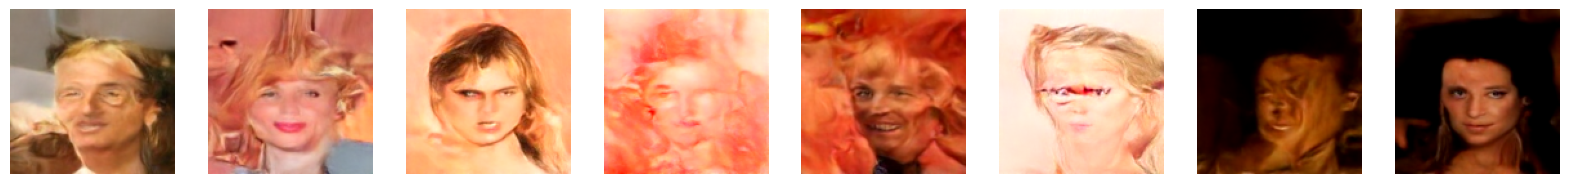

In [35]:
#Images generated by the model 
generated = sample(model.model, num_images=8, img_size=128, T=1000, betas=betas, device='cuda')

# Denormalize (reverse whatever Normalize() you used in data_transform, e.g. if mean=0.5,std=0.5)
generated = (generated * 0.5 + 0.5).clamp(0, 1)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i, ax in enumerate(axes):
    ax.imshow(generated[i].permute(1, 2, 0).cpu().numpy())
    ax.axis('off')
plt.show()